In [1]:
from pathlib import Path
import numpy as np

import hbn_pl.io as io
import hbn_pl.preprocess as preprocess
import hbn_pl.plot as plot
import hbn_pl.peaks as peaks

In [7]:
DATA_DIR = Path("C://Users/ech77/OneDrive - University of Cambridge/Data for IBS November 2025/Sample 5/PL spectra")
FILE_NAME = '2026 January 23 14_00_21 Sample7_uncapped_500uW_grating150_exposure20_emitter 59.spe'
FILE_NAME = '2025-11-17 17_21_59 sample5_DCMd2_200uw_emitter9 2187.spe'
spe_path = DATA_DIR / FILE_NAME
wavelength, frames = io.load_spe(spe_path)

Performing background subtraction...
Successfully subtracted background.


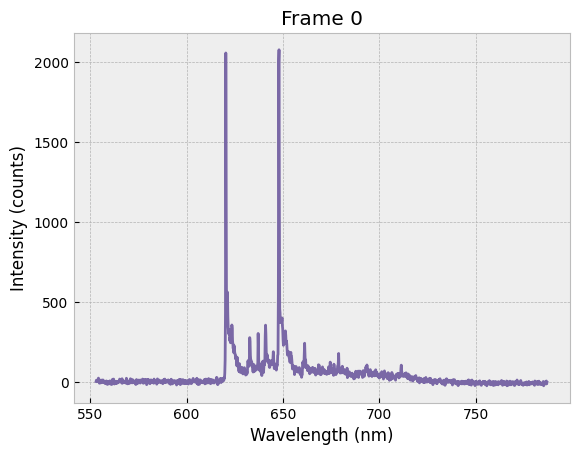

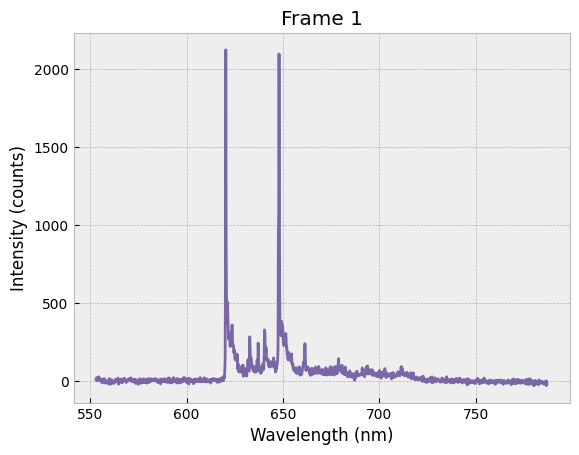

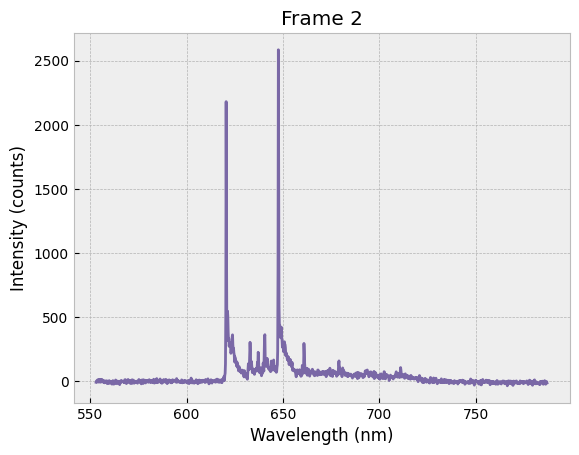

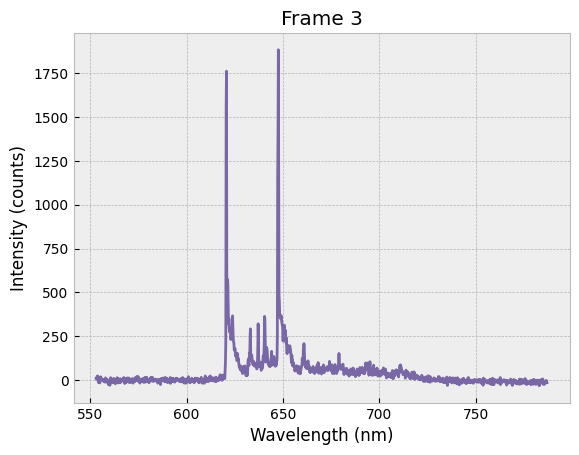

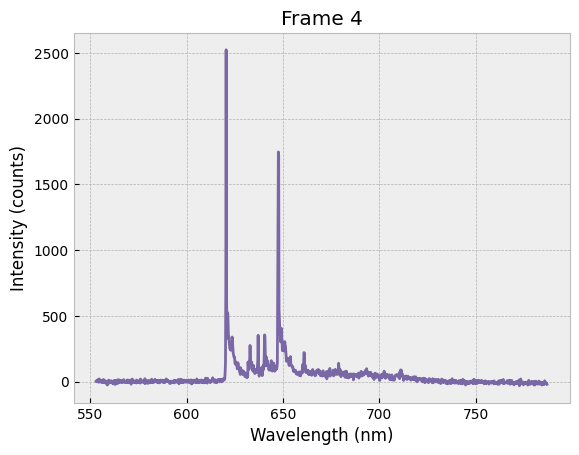

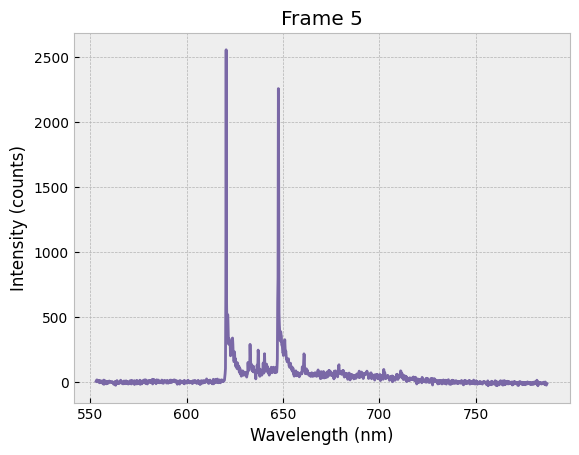

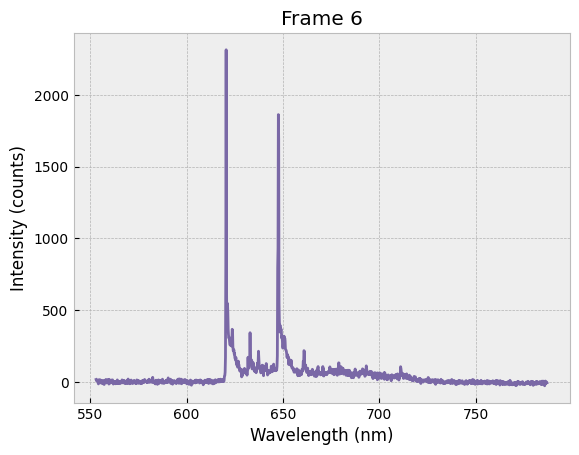

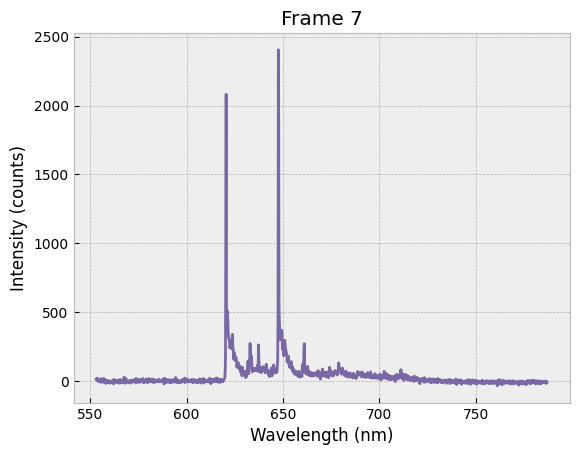

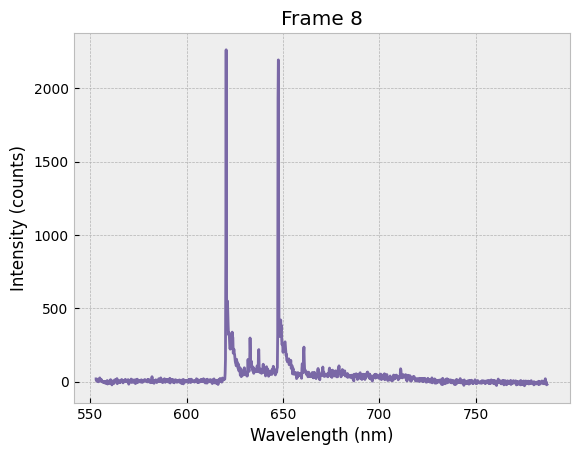

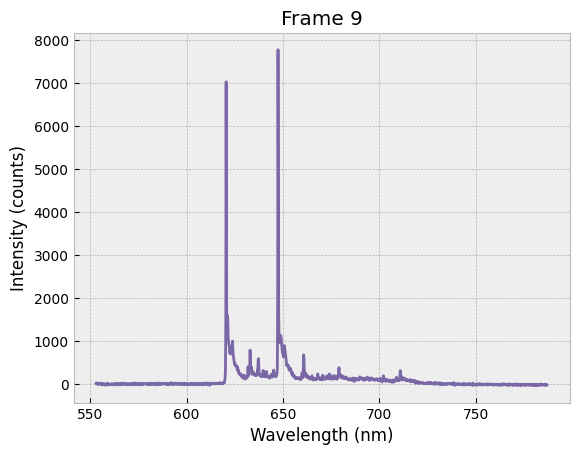

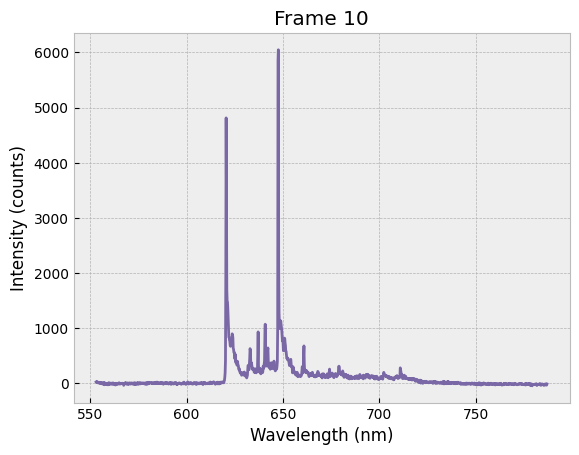

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

In [8]:
# Background subtraction
frames = preprocess.background_subtract(frames, bg_slice=(1, 50))
plot.plot_frames(frames, wavelength)

Detecting cosmic ray frames...
Detected 1 cosmic ray frames: [3]
Cosmic ray wavelengths: {3: [619.1173953880414]}
Cosmic ray detection complete.


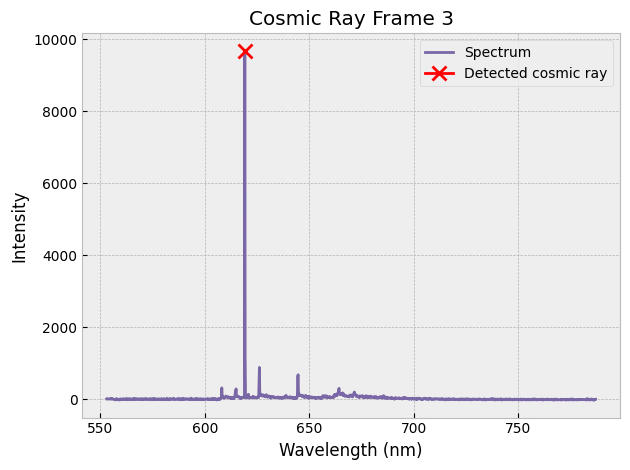

Removing cosmic rays from 1 frames: [3]


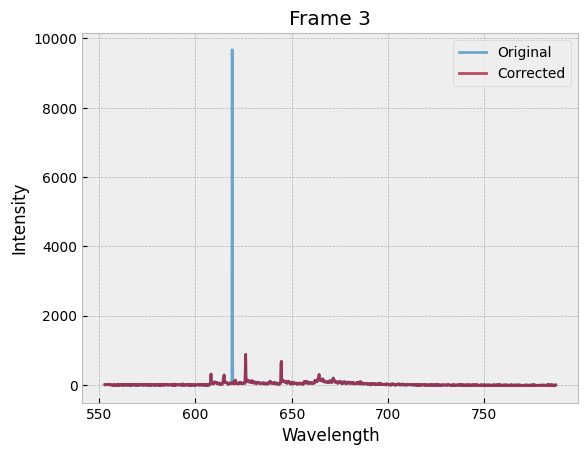

In [4]:
# Cosmic ray removal
cosmic_frames, cosmic_location = preprocess.detect_cosmic_frames(frames, wavelength,
prominence_threshold=0.05, fwhm_threshold=1.9, n_peaks=3, z_thresh=100, half_width=5, noise_width=30)
plot.plot_cosmic_frames(frames, wavelength, cosmic_location)
frames_cleaned, cosmic_figs = preprocess.remove_cosmic_rays(frames, wavelength, cosmic_frames, cosmic_location, sigma=1.5, half_width = 5)

In [5]:
# Bad frame removal
drop_fraction = 0.6
bad_frames = preprocess.detect_bad_frames_simple(frames, drop_fraction = drop_fraction)
frames = preprocess.remove_frames(frames, bad_frames)

Running simple bad frame detection...
Detected bad frames due to intensity drop 0.6: []
Removing 0 frames: []


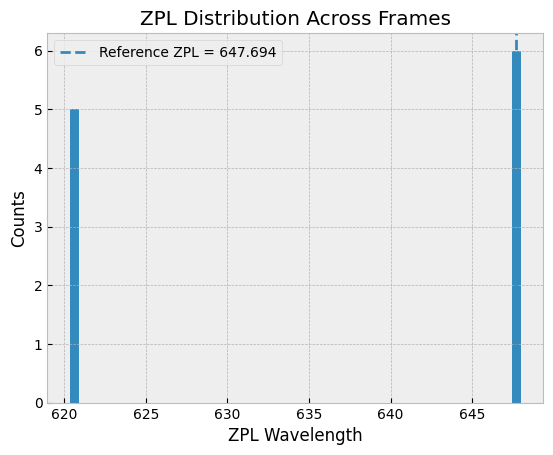

In [ ]:
#Line up ZPLs for many frames to fix spectral jumping
aligned_frames, zpls, ref_zpl = preprocess.align_zpl(frames, wavelength)

Averaging and normalising frames into a single spectrum...
Successfully averaged and normalised frames.


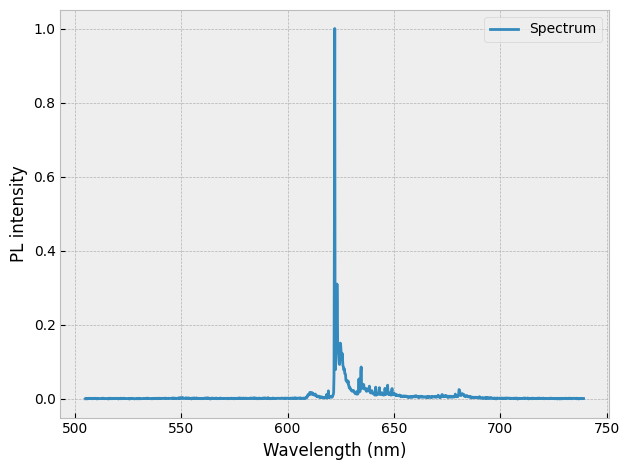

In [6]:
# Average frames and normalise
avg, avg_norm = preprocess.average_and_normalise(frames)
plot.plot_spectrum(x = wavelength, spectrum = avg_norm, x_quantity='Wavelength (nm)')

In [7]:
# Guess the ZPL wavelength by assuming it is the tallest peak in the spectrum
max_index = np.argmax(avg_norm)
zpl_wavelength = wavelength[max_index]
print("Estimated ZPL:", zpl_wavelength)

Estimated ZPL: 622.1749302999019


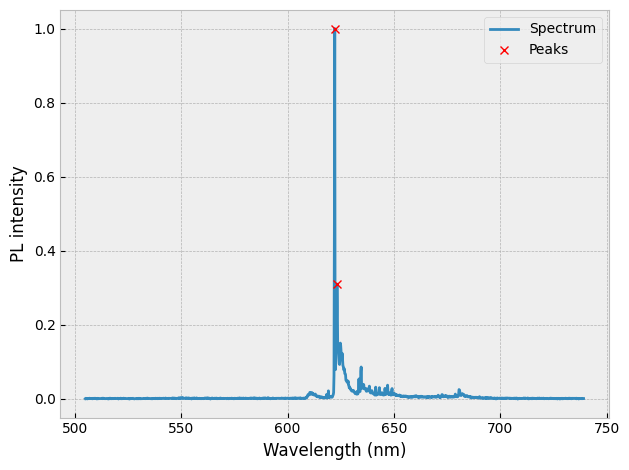

[{'location': np.float64(622.1749302999019), 'intensity': np.float64(1.0), 'fwhm': np.float64(0.17493029990191644), 'prominence': np.float64(0.9330092056111763)}, {'location': np.float64(623.2245076721188), 'intensity': np.float64(0.30945680416303795), 'fwhm': np.float64(0.5247870989633157), 'prominence': np.float64(0.23135665805365024)}]
Found ZPL-like peaks at wavelengths: [622.1749303  623.22450767]


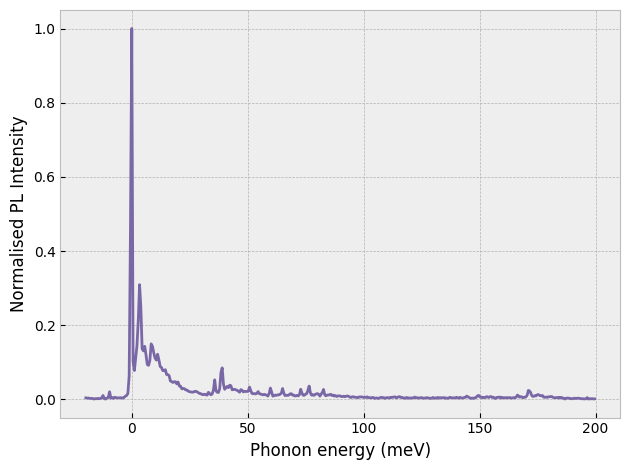

In [12]:
# Find ZPLs centred around the guessed ZPL wavelength
peaks_found, properties = peaks.find_peaks(avg_norm, x=wavelength, center_guess=zpl_wavelength, window=5, height=0.1, width = 0.5, prominence = 0.1)
peak_params = peaks.extract_peak_parameters(wavelength, avg_norm, peaks_found, properties)
plot.plot_spectrum(x = wavelength, spectrum = avg_norm, peaks=peaks_found, x_quantity='Wavelength (nm)')
plot.plot_energy(wavelength, avg_norm, zpl_wavelength=zpl_wavelength)
print(peak_params)
print("Found ZPL-like peaks at wavelengths:", wavelength[peaks_found])

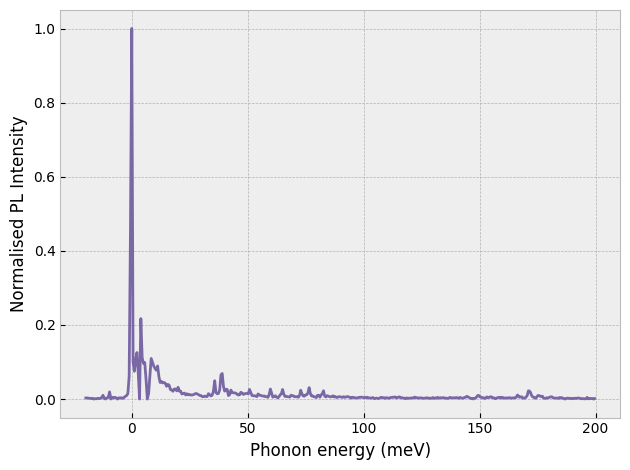

In [ ]:
intensity, energy, figure = plot.plot_energy(wavelength, avg_norm, zpl_wavelength)

In [11]:
io.save_preprocess_results(spe_path, intensity, energy, figure, zpl_wavelength)

Saved: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\2026 January 23 14_00_21 Sample7_uncapped_500uW_grating150_exposure20_emitter 59_cleaned.npz
Saved: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\2026 January 23 14_00_21 Sample7_uncapped_500uW_grating150_exposure20_emitter 59_cleaned.png
Updated: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\ZPL_wavelengths.csv
